In [4]:
!pip install torch


  Using cached torch-2.13.0-cp312-cp312-win_amd64.whl.metadata (39 kB)
  Using cached filelock-3.32.3-py3-none-any.whl.metadata (2.0 kB)
  Using cached setuptools-84.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached fsspec-2026.7.0-py3-none-any.whl.metadata (10 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached torch-2.13.0-cp312-cp312-win_amd64.whl (122.1 MB)
Using cached fsspec-2026.7.0-py3-none-any.whl (206 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached setuptools-84.0.0-py3-none-any.whl (818 kB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached filelock-3.32.3-py3-none-any.whl (98 kB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!pip install torchvision

  Using cached torchvision-0.28.0-cp312-cp312-win_amd64.whl.metadata (5.6 kB)
Using cached torchvision-0.28.0-cp312-cp312-win_amd64.whl (4.1 MB)



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
# ============================================================
# DeepShield-AI — Photo AI
# Cell 1: Environment & GPU Verification
# ============================================================

import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("========== ENVIRONMENT ==========")
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)
print("NumPy:", np.__version__)

print("\n========== DEVICE ==========")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("CUDA: Available")
    print("GPU:", torch.cuda.get_device_name(0))
    print("CUDA Version:", torch.version.cuda)
else:
    
    DEVICE = torch.device("cpu")
    print("CUDA: Not available")
    print("Using CPU")

print("\nUsing device:", DEVICE)

========== ENVIRONMENT ==========
PyTorch: 2.12.1+cu130
TorchVision: 0.27.1+cu130
NumPy: 2.5.2

========== DEVICE ==========
CUDA: Available
GPU: NVIDIA GeForce RTX 2050
CUDA Version: 13.0

Using device: cuda


In [3]:
from datasets import load_dataset

# Load stable CIFAKE dataset
dataset = load_dataset("dragonintelligence/CIFAKE-image-dataset")

print("Dataset loaded successfully!")
print(dataset)

print("\nTrain size:", len(dataset["train"]))
print("Test size :", len(dataset["test"]))

print("\nFeatures:")
print(dataset["train"].features)

print("\nLabel names:")
print(dataset["train"].features["label"].names)

Dataset loaded successfully!
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 100000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 20000
    })
})

Train size: 100000
Test size : 20000

Features:
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['FAKE', 'REAL'])}

Label names:
['FAKE', 'REAL']


In [4]:
from torchvision import transforms

# ImageNet statistics used by pretrained ResNet18
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training transformations
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),

    # Data augmentation
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.15
    ),

    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Validation/Test transformations
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print("Training transforms:")
print(train_transform)

print("\nValidation/Test transforms:")
print(val_transform)

Training transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.85, 1.15), contrast=(0.85, 1.15), saturation=(0.85, 1.15), hue=None)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation/Test transforms:
Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [5]:
from torch.utils.data import Dataset, DataLoader


split_dataset = dataset["train"].train_test_split(
    test_size=0.10,
    seed=42,
    stratify_by_column="label"
)

train_data = split_dataset["train"]
val_data = split_dataset["test"]

test_data = dataset["test"]

print("========== DATASET SPLIT ==========")
print("Training   :", len(train_data))
print("Validation :", len(val_data))
print("Test       :", len(test_data))



class CIFAKEDataset(Dataset):

    def __init__(self, hf_dataset, transform):
        self.dataset = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, index):

        item = self.dataset[index]

        image = item["image"]
        label = item["label"]

        # Make sure image is RGB
        image = image.convert("RGB")

        # Apply preprocessing
        image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)



train_dataset = CIFAKEDataset(
    train_data,
    train_transform
)

val_dataset = CIFAKEDataset(
    val_data,
    val_transform
)

test_dataset = CIFAKEDataset(
    test_data,
    val_transform
)



BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)



images, labels = next(iter(train_loader))

print("\n========== BATCH CHECK ==========")
print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)
print("Image dtype       :", images.dtype)
print("Label dtype       :", labels.dtype)
print("Labels in batch   :", labels[:10].tolist())

========== DATASET SPLIT ==========
Training   : 90000
Validation : 10000
Test       : 20000

========== BATCH CHECK ==========
Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32])
Image dtype       : torch.float32
Label dtype       : torch.int64
Labels in batch   : [1, 0, 0, 0, 0, 0, 1, 1, 0, 0]


In [6]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
weights = models.ResNet18_Weights.DEFAULT

model = models.resnet18(weights=weights)

# Replace the final classification layer
model.fc = nn.Linear(
    model.fc.in_features,
    2
)

# Move model to RTX 2050
model = model.to(DEVICE)

print(model.fc)
print("\nModel device:", next(model.parameters()).device)

Linear(in_features=512, out_features=2, bias=True)

Model device: cuda:0


In [7]:
import torch.optim as optim

# Classification loss
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

# Learning-rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

print("Loss function :", criterion)
print("Optimizer     :", optimizer.__class__.__name__)
print("Learning rate :", optimizer.param_groups[0]["lr"])
print("Scheduler     :", scheduler.__class__.__name__)

Loss function : CrossEntropyLoss()
Optimizer     : AdamW
Learning rate : 0.0001
Scheduler     : ReduceLROnPlateau


In [ ]:


EPOCHS = 10

BEST_MODEL_PATH = "../models/photo_resnet18_best.pth"

EARLY_STOPPING_PATIENCE = 3

print("========== TRAINING CONFIG ==========")
print("Epochs:", EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", optimizer.param_groups[0]["lr"])
print("Best model:", BEST_MODEL_PATH)
print("Early stopping patience:", EARLY_STOPPING_PATIENCE)

========== TRAINING CONFIG ==========
Epochs: 10
Batch size: 32
Learning rate: 0.0001
Best model: ../models/photo_resnet18_best.pth
Early stopping patience: 3


In [9]:
from tqdm.auto import tqdm

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

        progress.set_postfix(
            loss=f"{loss.item():.4f}"
        )

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy


print("Training and validation functions ready.")

Training and validation functions ready.


In [10]:
import os
import time

# Create model directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

history = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": []
}

best_val_loss = float("inf")
patience_counter = 0

print("=" * 60)
print("STARTING PHOTO AI TRAINING")
print("=" * 60)

for epoch in range(EPOCHS):

    start_time = time.time()

    # -------------------------
    # Training
    # -------------------------
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # -------------------------
    # Validation
    # -------------------------
    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # -------------------------
    # Save history
    # -------------------------
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)

    # -------------------------
    # Scheduler
    # -------------------------
    scheduler.step(val_loss)

    epoch_time = time.time() - start_time

    print(
        f"\nEpoch [{epoch + 1}/{EPOCHS}] "
        f"| Train Loss: {train_loss:.4f} "
        f"| Train Acc: {train_acc:.2f}% "
        f"| Val Loss: {val_loss:.4f} "
        f"| Val Acc: {val_acc:.2f}% "
        f"| Time: {epoch_time:.1f}s"
    )

    # -------------------------
    # Save best model
    # -------------------------
    if val_loss < best_val_loss:

        best_val_loss = val_loss
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "epoch": epoch + 1,
                "val_loss": val_loss,
                "val_accuracy": val_acc
            },
            BEST_MODEL_PATH
        )

        print("✓ Best model saved!")

    else:
        patience_counter += 1

        print(
            f"No improvement "
            f"({patience_counter}/{EARLY_STOPPING_PATIENCE})"
        )

    # -------------------------
    # Early stopping
    # -------------------------
    if patience_counter >= EARLY_STOPPING_PATIENCE:

        print("\nEarly stopping triggered.")
        break

print("\n" + "=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print("Best validation loss:", best_val_loss)
print("Model:", BEST_MODEL_PATH)

STARTING PHOTO AI TRAINING


Training:   0%|          | 0/2813 [00:00<?, ?it/s]


Epoch [1/10] | Train Loss: 0.1497 | Train Acc: 94.12% | Val Loss: 0.0841 | Val Acc: 96.77% | Time: 954.9s
✓ Best model saved!


Training:   0%|          | 0/2813 [00:00<?, ?it/s]


Epoch [2/10] | Train Loss: 0.0987 | Train Acc: 96.29% | Val Loss: 0.0730 | Val Acc: 97.15% | Time: 1813.0s
✓ Best model saved!


...


Epoch [6/10] | Train Loss: 0.0498 | Train Acc: 98.15% | Val Loss: 0.0578 | Val Acc: 98.01% | Time: 770.9s
No improvement (1/3)


Training:   0%|          | 0/2813 [00:00<?, ?it/s]


Epoch [7/10] | Train Loss: 0.0448 | Train Acc: 98.35% | Val Loss: 0.0604 | Val Acc: 97.72% | Time: 748.9s
No improvement (2/3)


Training:   0%|          | 0/2813 [00:00<?, ?it/s]


Epoch [8/10] | Train Loss: 0.0391 | Train Acc: 98.54% | Val Loss: 0.0639 | Val Acc: 97.64% | Time: 707.0s
No improvement (3/3)

Early stopping triggered.

TRAINING COMPLETE
Best validation loss: 0.057779437897726896
Model: ../models/photo_resnet18_best.pth


In [11]:
from pathlib import Path
import torch

# Find the saved model regardless of notebook working directory
possible_paths = [
    Path("models/photo_resnet18_best.pth"),
    Path("../models/photo_resnet18_best.pth")
]

MODEL_PATH = next(
    (p for p in possible_paths if p.exists()),
    None
)

if MODEL_PATH is None:
    raise FileNotFoundError(
        "Best model not found. Check the models folder."
    )

print("Loading model from:", MODEL_PATH)

checkpoint = torch.load(
    MODEL_PATH,
    map_location=DEVICE
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(DEVICE)

print("\nBest checkpoint:")
print("Epoch:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["val_loss"])
print("Validation Accuracy:", checkpoint["val_accuracy"])

print("\nModel loaded successfully!")

Loading model from: ..\models\photo_resnet18_best.pth

Best checkpoint:
Epoch: 5
Validation Loss: 0.057779437897726896
Validation Accuracy: 97.95

Model loaded successfully!


In [12]:
import numpy as np
from tqdm.auto import tqdm

model.eval()

all_labels = []
all_predictions = []
all_probabilities = []

with torch.no_grad():

    for images, labels in tqdm(
        test_loader,
        desc="Testing"
    ):

        images = images.to(DEVICE, non_blocking=True)

        outputs = model(images)

        # Probability of REAL class
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        predictions = torch.argmax(
            probabilities,
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_probabilities.extend(
            probabilities[:, 1].cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)
all_probabilities = np.array(all_probabilities)

print("\n========== TEST INFERENCE COMPLETE ==========")
print("Test samples:", len(all_labels))
print("Predictions :", len(all_predictions))
print("Probabilities:", len(all_probabilities))

Testing:   0%|          | 0/625 [00:00<?, ?it/s]


========== TEST INFERENCE COMPLETE ==========
Test samples: 20000
Predictions : 20000
Probabilities: 20000


DEEPSHIELD-AI — PHOTO MODEL EVALUATION
Accuracy  : 0.9784 (97.84%)
Precision : 0.9833
Recall    : 0.9732
F1 Score  : 0.9782
ROC-AUC   : 0.9976

Classification Report:
              precision    recall  f1-score   support

        FAKE     0.9735    0.9835    0.9785     10000
        REAL     0.9833    0.9732    0.9782     10000

    accuracy                         0.9784     20000
   macro avg     0.9784    0.9784    0.9783     20000
weighted avg     0.9784    0.9784    0.9783     20000


Confusion Matrix:
[[9835  165]
 [ 268 9732]]


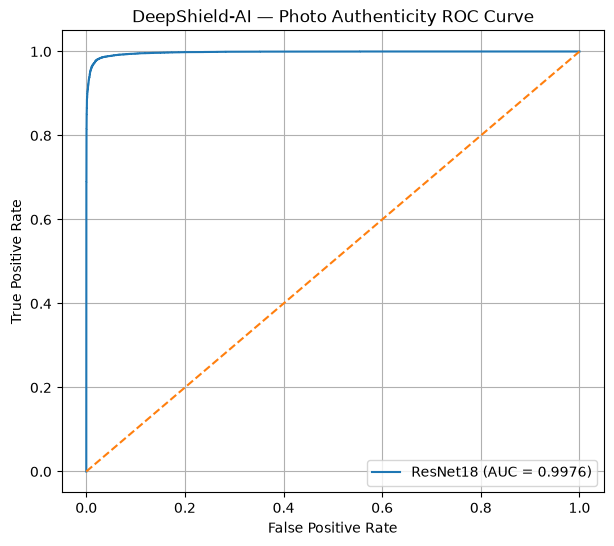

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

# --------------------------------------------------
# Metrics
# --------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions
)

recall = recall_score(
    all_labels,
    all_predictions
)

f1 = f1_score(
    all_labels,
    all_predictions
)

roc_auc = roc_auc_score(
    all_labels,
    all_probabilities
)

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 55)
print("DEEPSHIELD-AI — PHOTO MODEL EVALUATION")
print("=" * 55)

print(f"Accuracy  : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=["FAKE", "REAL"],
        digits=4
    )
)

print("\nConfusion Matrix:")
print(cm)


# --------------------------------------------------
# ROC Curve
# --------------------------------------------------

fpr, tpr, thresholds = roc_curve(
    all_labels,
    all_probabilities
)

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"ResNet18 (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("DeepShield-AI — Photo Authenticity ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

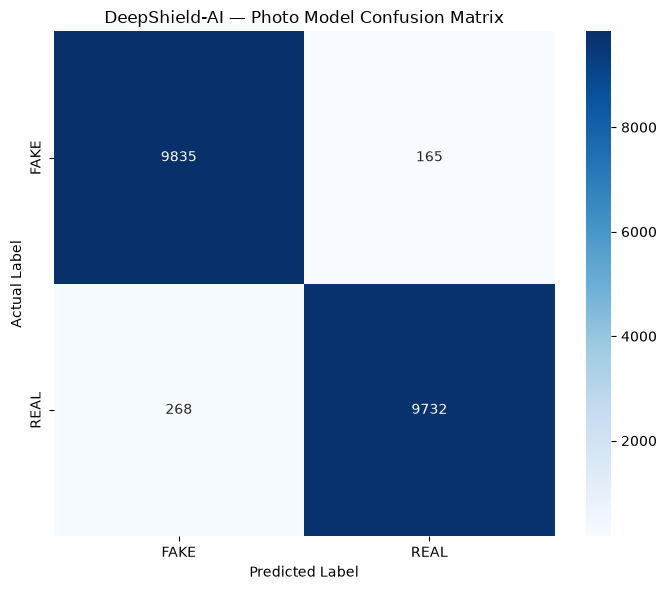

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["FAKE", "REAL"],
    yticklabels=["FAKE", "REAL"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("DeepShield-AI — Photo Model Confusion Matrix")

plt.tight_layout()
plt.show()

In [15]:
import json
from pathlib import Path

results = {
    "model": "ResNet18",
    "task": "Photo Authenticity Detection",
    "accuracy": float(accuracy),
    "precision": float(precision),
    "recall": float(recall),
    "f1_score": float(f1),
    "roc_auc": float(roc_auc),
    "confusion_matrix": cm.tolist()
}

results_path = Path("../models/photo_metrics.json")

with open(results_path, "w") as f:
    json.dump(results, f, indent=4)

print("Metrics saved to:", results_path)

Metrics saved to: ..\models\photo_metrics.json


In [16]:
%pip install grad-cam

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
   ---------------------------------------- 0.0/43.8 MB ? eta -:--:--
   -- ------------------------------------- 3.1/43.8 MB 61.4 MB/s eta 0:00:01
   ---- ----------------------------------- 4.5/43.8 MB 12.8 MB/s eta 0:00:04
   ---- ----------------------------------- 5.2/43.8 MB 8.4 MB/s eta 0:00:05
   ----- ---------------------------------- 6.0/43.8 MB 9.2 MB/s eta 0:00:05
   ------ --------------------------------- 7.6/43.8 MB 7.7 MB/s eta 0:00:05
   ------- -------------------------------- 8.7/43.8 MB 6.9 MB/s eta 0:00:06
   -------- ------------------------------- 9.4/43.8 MB 6.6 MB/s eta 0:00:06
   --------- ------------------------------ 10.2/43.8 MB 6.


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

print("Grad-CAM imported successfully")

Grad-CAM imported successfully


In [18]:
print("Model:", type(model).__name__)
print("Device:", next(model.parameters()).device)

Model: ResNet
Device: cuda:0
